In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio


In [2]:
bands = {
    'red': 'SR_B4.TIF',
    'nir': 'SR_B5.TIF',
    'swir': 'SR_B6.TIF',
    'lst': 'ST_B10.TIF',
}

for name, path in bands.items():
  print(f'{name}: {"Found" if os.path.exists(path) else "MISSING - check path"}')

red: Found
nir: Found
swir: Found
lst: Found


In [3]:
# 1. Read bands as float32
with rasterio.open(bands['red']) as src:
  b4 = src.read(1).astype('float32')
with rasterio.open(bands['nir']) as src:
  b5 = src.read(1).astype('float32')
with rasterio.open(bands['swir']) as src:
  b6 = src.read(1).astype('float32')
with rasterio.open(bands['lst']) as src:
  b10 = src.read(1).astype('float32')

# 2. Scale factor conversions
b4_refl = (b4 * 0.0000275) - 0.2
b5_refl = (b5 * 0.0000275) - 0.2
b6_refl = (b6 * 0.0000275) - 0.2
lst_celsius = ((b10 * 0.00341802) + 149.0) - 273.15

# 3. Calculate NDVI (vegetation) and NDBI (built-up)
np.seterr(divide='ignore', invalid='ignore')
ndvi = (b5_refl - b4_refl) / (b5_refl + b4_refl)
ndbi = (b6_refl - b5_refl) / (b6_refl + b5_refl)

# 4. Build DataFrame and filter anomalous/cloud/water values
df = pd.DataFrame({
    'NDVI': ndvi.flatten(),
    'NDBI': ndbi.flatten(),
    'Red': b4_refl.flatten(),
    'NIR': b5_refl.flatten(),
    'SWIR': b6_refl.flatten(),
    'LST_Celsius': lst_celsius.flatten(),
}).dropna()

df = df[(df['NDVI'] >= -1.0) & (df['NDVI'] <= 1.0)]
df = df[(df['NDBI'] >= -1.0) & (df['NDBI'] <= 1.0)]
df = df[(df['LST_Celsius'] > 15) & (df['LST_Celsius'] < 60)]

# Sample 100,000 points to keep execution fast in VS Code
data = df.sample(n=100000, random_state=42)
data.head()

,NDVI,NDBI,Red,NIR,SWIR,LST_Celsius
26510935,0.346821,-0.050848,0.136160,0.280755,0.253585,45.305176
51713227,0.322430,0.029268,0.194405,0.379425,0.402305,51.013275
33057612,0.246532,0.003953,0.165447,0.273715,0.275887,21.847321
11697727,0.321864,0.100487,0.130770,0.254905,0.311858,49.557220
6209156,0.293077,0.023931,0.163110,0.298355,0.312985,40.280670


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Define Features and Target
X = data[['NDVI', 'NDBI', 'Red', 'NIR', 'SWIR']]
y = data['LST_Celsius']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, max_depth=15, n_jobs=-1, random_state=42
    ),
}

# Train and evaluate
results = []
for name, model in models.items():
  model.fit(X_train, y_train)
  preds = model.predict(X_test)

  r2 = r2_score(y_test, preds)
  mae = mean_absolute_error(y_test, preds)
  rmse = np.sqrt(mean_squared_error(y_test, preds))

  results.append({'Model': name, 'R2 Score': r2, 'MAE (°C)': mae, 'RMSE (°C)': rmse})

results_df = pd.DataFrame(results)
results_df

,Model,R2 Score,MAE (°C),RMSE (°C)
0,Linear Regression,0.213720,4.191468,5.966081
1,Ridge Regression,0.213591,4.193248,5.966571
2,Random Forest,0.319613,3.771540,5.549818


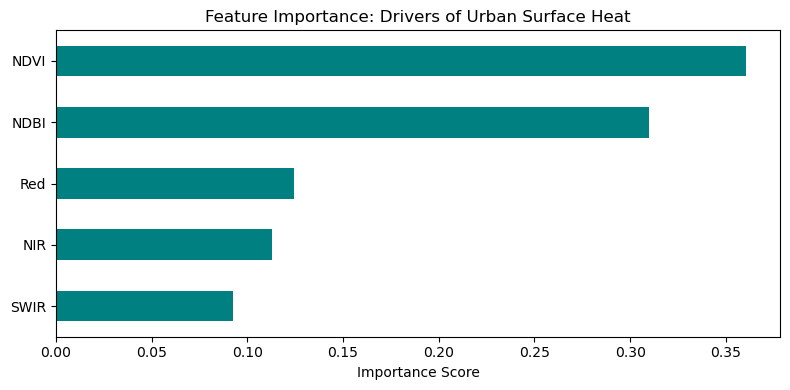

In [5]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

plt.figure(figsize=(8, 4))
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance: Drivers of Urban Surface Heat')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Average Cooling Effect from Adding Greenery: 8.08 °C
Maximum Local Cooling Observed: 15.58 °C


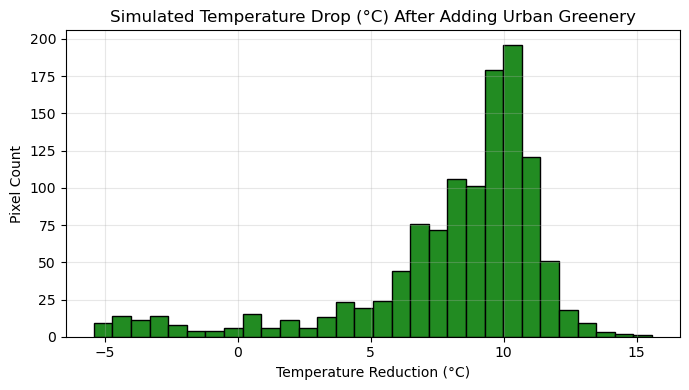

In [6]:
# 1. Isolate high-heat urban hotspots (hot, low vegetation, high built-up)
hotspots = data[
    (data['LST_Celsius'] > data['LST_Celsius'].quantile(0.85))
    & (data['NDVI'] < 0.2)
].copy()

# 2. Simulate intervention: increase NDVI by +0.3 (planting trees / parks)
simulated_hotspots = hotspots.copy()
simulated_hotspots['NDVI'] = np.clip(simulated_hotspots['NDVI'] + 0.3, -1.0, 1.0)
simulated_hotspots['NDBI'] = np.clip(
    simulated_hotspots['NDBI'] - 0.2, -1.0, 1.0
)  # replaces concrete

# 3. Predict new surface temperature using the trained Random Forest model
features = ['NDVI', 'NDBI', 'Red', 'NIR', 'SWIR']
hotspots['Predicted_Original_LST'] = rf_model.predict(hotspots[features])
hotspots['Predicted_Cooled_LST'] = rf_model.predict(
    simulated_hotspots[features]
)
hotspots['Cooling_Effect_C'] = (
    hotspots['Predicted_Original_LST'] - hotspots['Predicted_Cooled_LST']
)

# 4. View results
print(
    f"Average Cooling Effect from Adding Greenery: {hotspots['Cooling_Effect_C'].mean():.2f} °C"
)
print(f"Maximum Local Cooling Observed: {hotspots['Cooling_Effect_C'].max():.2f} °C")

# Plot the distribution of cooling impact
plt.figure(figsize=(7, 4))
plt.hist(
    hotspots['Cooling_Effect_C'],
    bins=30,
    color='forestgreen',
    edgecolor='black',
)
plt.title('Simulated Temperature Drop (°C) After Adding Urban Greenery')
plt.xlabel('Temperature Reduction (°C)')
plt.ylabel('Pixel Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
import folium
from folium.plugins import HeatMap, MarkerCluster
import geopandas as gpd
import numpy as np
import pandas as pd
from pyproj import Transformer
import rasterio

# 1. Open the thermal band to access spatial metadata and transform
with rasterio.open(bands['lst']) as src:
  transform = src.transform
  crs = src.crs
  lst_band = src.read(1).astype('float32')

# Recalculate Celsius temperature grid
lst_c = ((lst_band * 0.00341802) + 149.0) - 273.15

# 2. Identify top 10% hottest urban pixels
temp_threshold = np.nanpercentile(lst_c[(lst_c > 15) & (lst_c < 60)], 90)
hot_rows, hot_cols = np.where((lst_c >= temp_threshold) & (lst_c < 60))

# Subsample 1,500 hotspots for smooth, lag-free browser rendering
subsample_indices = np.random.choice(len(hot_rows), size=1500, replace=False)
selected_rows = hot_rows[subsample_indices]
selected_cols = hot_cols[subsample_indices]

# 3. Convert pixel (row, col) to map coordinates (Projected CRS)
xs, ys = rasterio.transform.xy(transform, selected_rows, selected_cols)

# 4. Transform projected coordinates (UTM) to standard GPS Lat/Lon (EPSG:4326)
transformer = Transformer.from_crs(crs, 'EPSG:4326', always_xy=True)
lons, lats = transformer.transform(xs, ys)

# 5. Build a GeoDataFrame
hotspots_geo_df = pd.DataFrame({
    'Latitude': lats,
    'Longitude': lons,
    'LST_Celsius': lst_c[selected_rows, selected_cols],
})

gdf_hotspots = gpd.GeoDataFrame(
    hotspots_geo_df,
    geometry=gpd.points_from_xy(
        hotspots_geo_df.Longitude, hotspots_geo_df.Latitude
    ),
    crs='EPSG:4326',
)

print(f'Extracted {len(gdf_hotspots)} hotspot points.')
print(f'Temperature Threshold: {temp_threshold:.2f} °C')
gdf_hotspots.head()

Extracted 1500 hotspot points.
Temperature Threshold: 54.43 °C


,Latitude,Longitude,LST_Celsius,geometry
0,17.295518,78.061713,54.516754,POINT (78.06171 17.29552)
1,17.096653,78.963389,54.803864,POINT (78.96339 17.09665)
2,17.221740,77.963950,55.948883,POINT (77.96395 17.22174)
3,17.313731,77.493589,55.839508,POINT (77.49359 17.31373)
4,17.249898,77.623860,56.389801,POINT (77.62386 17.2499)


In [8]:
# Center map on Hyderabad
hyderabad_center = [gdf_hotspots['Latitude'].mean(), gdf_hotspots['Longitude'].mean()]
m = folium.Map(
    location=hyderabad_center,
    zoom_start=11,
    tiles="OpenStreetMap",  # Clean basemap that highlights heat overlays
)

# Layer 1: Continuous HeatMap Density Layer
heat_data = [
    [row["Latitude"], row["Longitude"], float(row["LST_Celsius"])]
    for _, row in gdf_hotspots.iterrows()
]
HeatMap(
    heat_data,
    radius=14,
    blur=18,
    max_zoom=13,
    gradient={0.4: "blue", 0.65: "orange", 1: "red"},
).add_to(m)

# Layer 2: Clickable Hotspot Markers with Suggested Interventions
marker_cluster = MarkerCluster(name="Priority Intervention Points").add_to(m)

for _, row in gdf_hotspots.iterrows():
  popup_html = f"""
    <div style="font-family: Arial; width: 170px;">
        <b>Surface Heat Hotspot</b><br>
        <b>Measured LST:</b> {row['LST_Celsius']:.1f} °C<br>
        <b>Action:</b> High priority for canopy planting / reflective cool roofs.
    </div>
    """
  folium.CircleMarker(
      location=[row["Latitude"], row["Longitude"]],
      radius=4,
      color="#d63031",
      fill=True,
      fill_color="#ff7675",
      fill_opacity=0.8,
      popup=folium.Popup(popup_html, max_width=250),
  ).add_to(marker_cluster)

# Add layer control to toggle markers on/off
folium.LayerControl().add_to(m)

# Save to an standalone HTML file and display directly in VS Code
m.save("hyderabad_urban_heat_map.html")
print("Map exported successfully to 'hyderabad_urban_heat_map.html'")
m

Map exported successfully to 'hyderabad_urban_heat_map.html'
